# Tutorial 15 - add_soc

## Step 0: Setup the project and prepare the data

In [11]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [12]:
eet.set_logging_style("ERROR")

In [13]:
standardized_data = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers" / "Cal_Ageing_Checkup1.xlsx"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

In [14]:
segmented_data = eet.add_primitive_segments(
    df=standardized_data,
    config=eet.PrimitiveConfig.DEFAULT,
)

In [15]:
eet.BatteryConfig.DEFAULT

_BatteryConfigClass(cell_name='Default', c_ref=None, soc_start=0, max_voltage=4.2, min_voltage=2.5, threshold_current=0.075, voltage_intervall=0.01, minimal_current_for_capacity=-1.2, maximal_current_for_capacity=-0.8, min_current_diff=1, max_time_diff=0.5, min_voltage_diff=0, ignore_negative_resistance_values=False)

## Step 1: add_soc

<Axes: xlabel='Test_Time[s]'>

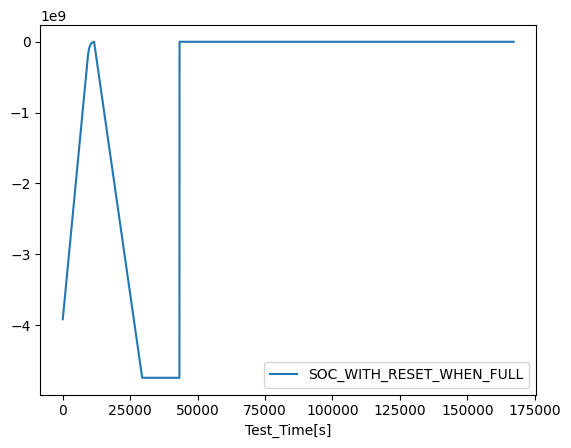

In [25]:
eet.add_soc(
    df=standardized_data,
    df_primitives=segmented_data,
    config=eet.BatteryConfig.DEFAULT,
    methods=[eet.SocMethod.WITH_RESET_WHEN_FULL],
    verbose=True,
).plot(x="Test_Time[s]", y="SOC_WITH_RESET_WHEN_FULL")